# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('data/bank_fin.zip', sep = ';')

###### Данные о клиентах банка:
- `age` (возраст);
- `job` (сфера занятости);
- `marital` (семейное положение);
- `education` (уровень образования);
- `default` (имеется ли просроченный кредит);
- `housing` (имеется ли кредит на жильё);
- `loan` (имеется ли кредит на личные нужды);
- `balance` (баланс).

##### Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:
- `contact` (тип контакта с клиентом);
- `month` (месяц, в котором был последний контакт);
- `day` (день, в который был последний контакт);
- `duration` (продолжительность контакта в секундах).

##### Прочие признаки:
- `campaign` (количество контактов с этим клиентом в течение текущей кампании);
- `pdays` (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
- `previous` (количество контактов до текущей кампании)
- `poutcome` (результат прошлой маркетинговой кампании).

И, разумеется, наша целевая переменная 
- `deposit`, которая определяет, согласится ли клиент открыть депозит в банке. 

Именно её мы будем пытаться предсказать в данном кейсе.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [4]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
all_row = df.shape[0]

cols_null = df.isnull().sum()
cols_with_null = cols_null[cols_null>0].sort_values(ascending=False)
print(cols_with_null)

balance    25
dtype: int64


### Задание 2

In [5]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [6]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = (df['balance']
                    .str.replace(' ','')
                    .str.replace('$','')
                    .str.replace(',','.')
                    .astype(np.float64)
)
round(df['balance'].mean(),3)

np.float64(1529.129)

### Задание 4

In [7]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
df['balance'] = df['balance'].fillna(df['balance'].median())
round(df['balance'].mean(),3)

np.float64(1526.936)

### Задание 5

In [8]:
df['job'] = df['job'].apply(lambda x: df['job'].mode()[0] if x == 'unknown' else x)
df['education'] = df['education'].apply(lambda x: df['education'].mode()[0] if x == 'unknown' else x)

display(df['job'].value_counts().idxmax())
display(df['education'].value_counts().idxmax())

'management'

'secondary'

In [9]:
mask = df['job'] == df['job'].value_counts().idxmax()
mask &= df['education'] == df['education'].value_counts().idxmax()

avg_popular = df[mask]['balance'].mean()
print(round(avg_popular,3))

1598.883


### Задание 6

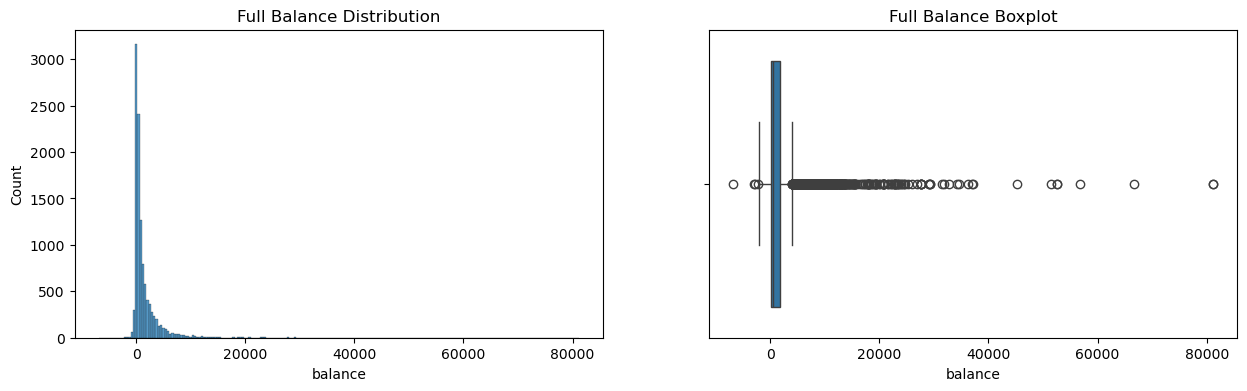

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=df, x='balance', ax=axes[0]);
histplot.set_title('Full Balance Distribution');
boxplot = sns.boxplot(data=df, x='balance', ax=axes[1]);
boxplot.set_title('Full Balance Boxplot');

In [11]:
def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned, lower_bound, upper_bound

In [12]:
# Применим эту функцию к таблице sber_data и признаку full_sq, а также выведем размерности результатов:
outliers, df_clean, lower, upper = outliers_iqr(df, 'balance')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {df_clean.shape[0]}')
print(f'от {lower}  до {upper}')

Число выбросов по методу Тьюки: 1057
Результирующее число записей: 10105
от -2241.0  до 4063.0


## Часть 2:  Разведывательный анализ

### Задание 1

In [13]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
deposit_counts = df_clean['deposit'].value_counts()

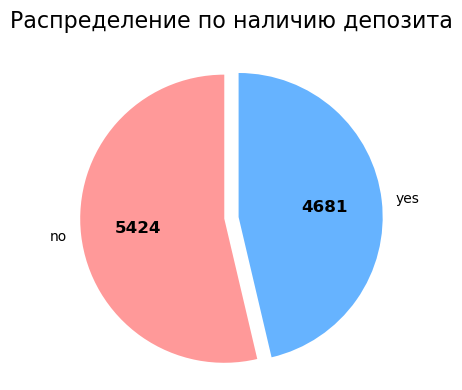

In [14]:
plt.figure(figsize=(4, 4))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
wedges, texts, autotexts = plt.pie(
    deposit_counts.values,
    labels=deposit_counts.index,
    #autopct='%1.1f%%', #доля
    autopct=lambda val: f'{round(val / 100 * sum(deposit_counts.values))}',  # абсолютное значение
    startangle=90,
    colors=colors,
    explode=[0.05] * len(deposit_counts)  # небольшой отступ для всех сегментов
)
plt.title('Распределение по наличию депозита', fontsize=16, pad=20)
plt.setp(autotexts, size=12, weight='bold')
plt.axis('equal')  # делаем круг идеальным
plt.tight_layout()
plt.show()

### Задания 2 и 3

In [15]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
df_clean.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 4 и 5

In [16]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
df_clean.describe(include='object')
#постройте визуализации, иллюстрирующие результаты

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


### Задание 6

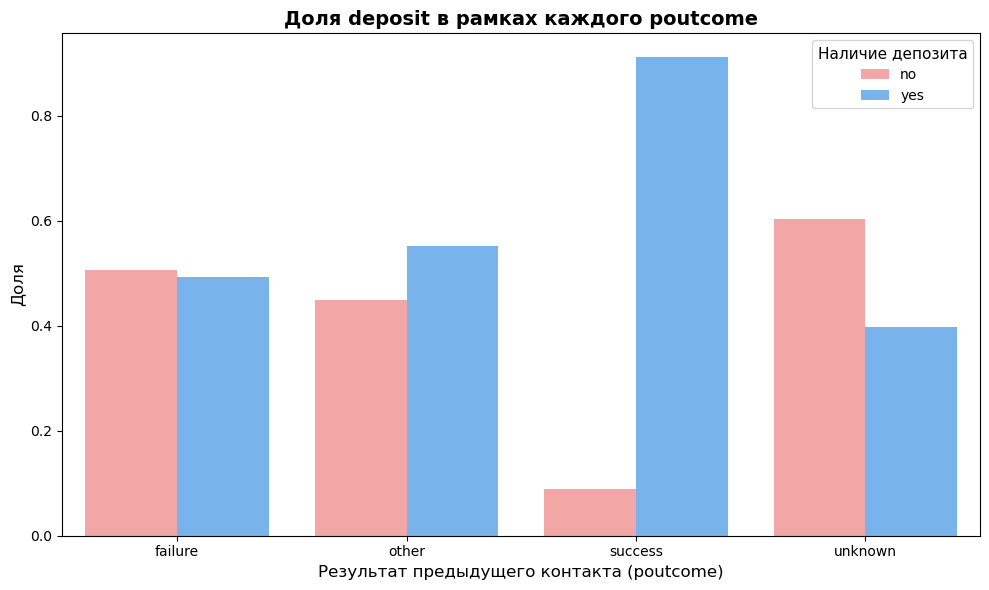

In [17]:
# Исходные данные
proportions = df_clean.groupby('poutcome')['deposit'].value_counts(normalize=True)

# Преобразуем в DataFrame для Seaborn
proportions_df = proportions.reset_index()
proportions_df.columns = ['poutcome', 'deposit', 'proportion']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=proportions_df,
    x='poutcome',
    y='proportion',
    hue='deposit',
    palette={'no': '#ff9999', 'yes': '#66b3ff'}
)
plt.title('Доля deposit в рамках каждого poutcome', fontsize=14, fontweight='bold')
plt.xlabel('Результат предыдущего контакта (poutcome)', fontsize=12)
plt.ylabel('Доля', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Наличие депозита', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

### Задание 7

<Axes: xlabel='month', ylabel='deposit'>

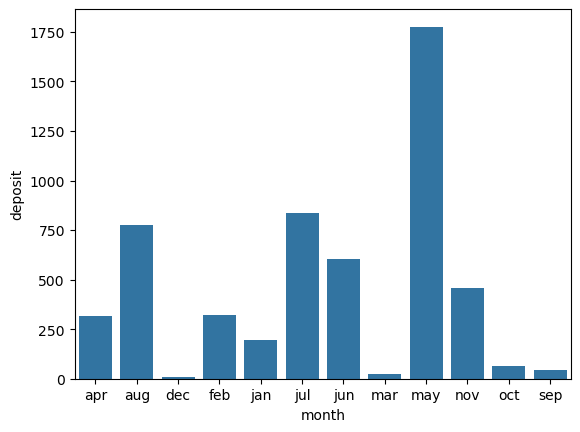

In [18]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
mont_no_deposit = df_clean[df_clean['deposit']=='no'].groupby(by='month')['deposit'].count()
sns.barplot(mont_no_deposit)

### Задание 8

In [19]:
def age_kateg(age):
    """Определяет категорию возрастной группы"""
    if age < 30:
        return '<30'
    if age >= 30 and age < 40:
        return '30-40'
    if age >= 40 and age < 50:
        return '40-50'
    if age >= 50 and age < 60:
        return '50-60'

    return '60+'

In [20]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
df_clean['age_group'] = df_clean['age'].apply(age_kateg)

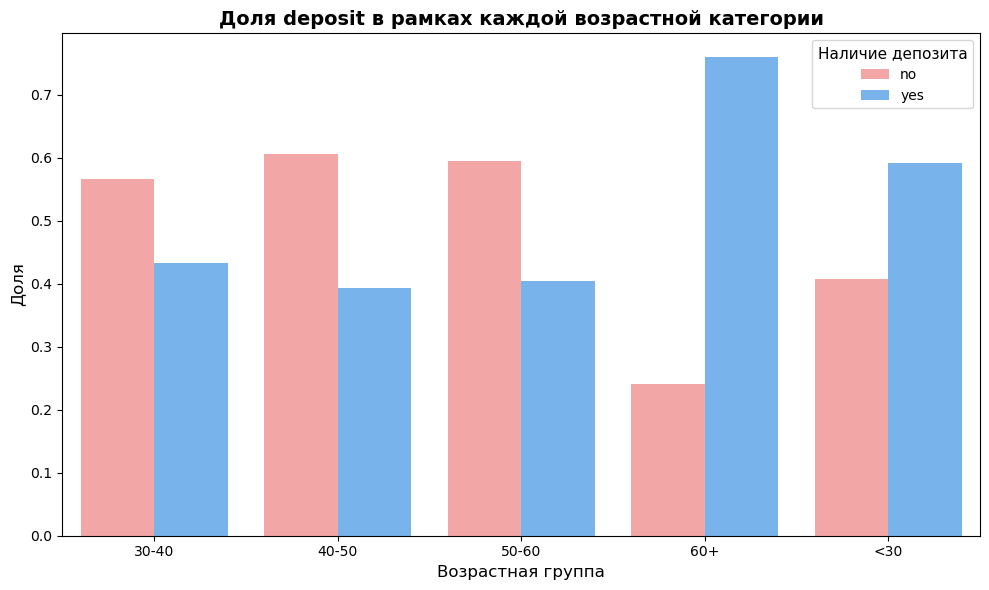

In [21]:
# Исходные данные
proportions = df_clean.groupby('age_group')['deposit'].value_counts(normalize=True)

# Преобразуем в DataFrame для Seaborn
proportions_df = proportions.reset_index()
proportions_df.columns = ['age_group', 'deposit', 'proportion']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=proportions_df,
    x='age_group',
    y='proportion',
    hue='deposit',
    palette={'no': '#ff9999', 'yes': '#66b3ff'}
)
plt.title('Доля deposit в рамках каждой возрастной категории', fontsize=14, fontweight='bold')
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Наличие депозита', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

### Задания 9 и 10

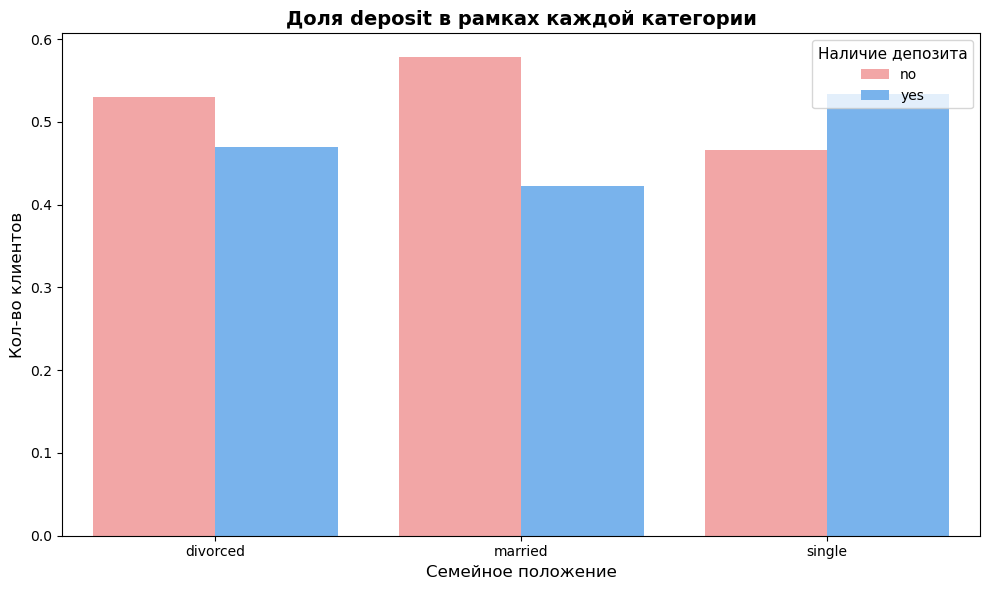

In [22]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
proportions = df_clean.groupby('marital')['deposit'].value_counts(normalize=True)

# Преобразуем в DataFrame для Seaborn
proportions_df = proportions.reset_index()
proportions_df.columns = ['marital', 'deposit', 'proportion']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=proportions_df,
    x='marital',
    y='proportion',
    hue='deposit',
    palette={'no': '#ff9999', 'yes': '#66b3ff'}
)
plt.title('Доля deposit в рамках каждой категории', fontsize=14, fontweight='bold')
plt.xlabel('Семейное положение', fontsize=12)
plt.ylabel('Кол-во клиентов', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Наличие депозита', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

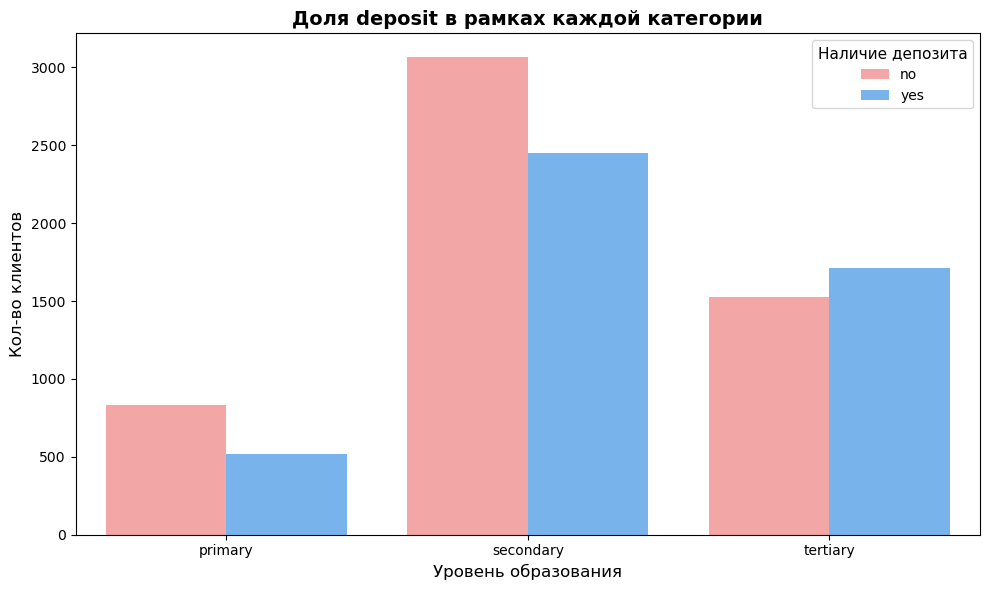

In [23]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
proportions = df_clean.groupby('education')['deposit'].value_counts()

# Преобразуем в DataFrame для Seaborn
proportions_df = proportions.reset_index()
proportions_df.columns = ['education', 'deposit', 'proportion']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=proportions_df,
    x='education',
    y='proportion',
    hue='deposit',
    palette={'no': '#ff9999', 'yes': '#66b3ff'}
)
plt.title('Доля deposit в рамках каждой категории', fontsize=14, fontweight='bold')
plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Кол-во клиентов', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Наличие депозита', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

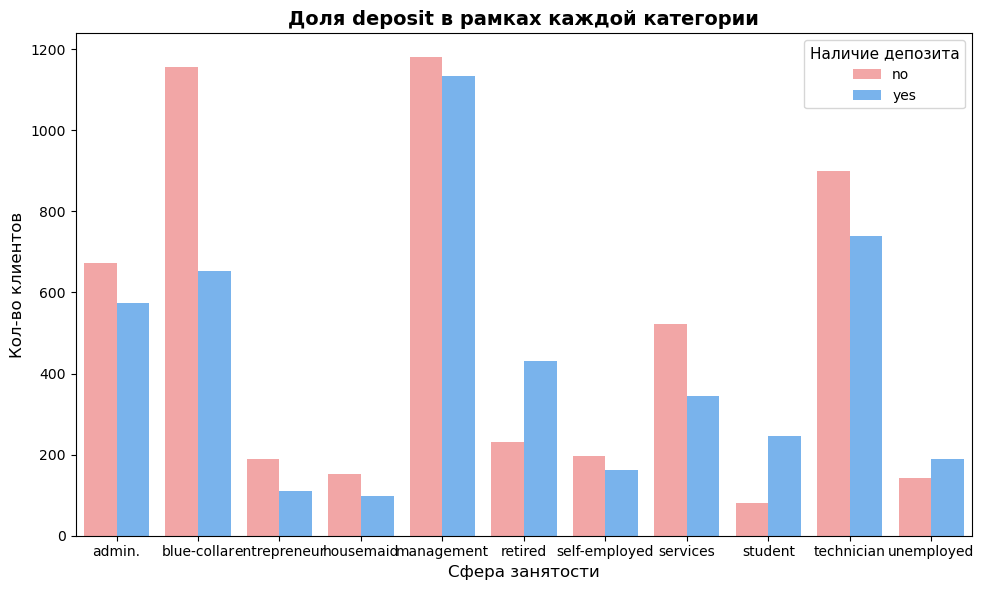

In [24]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
proportions = df_clean.groupby('job')['deposit'].value_counts()

# Преобразуем в DataFrame для Seaborn
proportions_df = proportions.reset_index()
proportions_df.columns = ['job', 'deposit', 'proportion']

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
sns.barplot(
    data=proportions_df,
    x='job',
    y='proportion',
    hue='deposit',
    palette={'no': '#ff9999', 'yes': '#66b3ff'}
)
plt.title('Доля deposit в рамках каждой категории', fontsize=14, fontweight='bold')
plt.xlabel('Сфера занятости', fontsize=12)
plt.xticks(rotation= 90)
plt.ylabel('Кол-во клиентов', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Наличие депозита', title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()

### Задание 11

In [25]:
df_deposit = df_clean[df_clean['deposit']=='yes']
df_no_deposit = df_clean[df_clean['deposit']=='no']

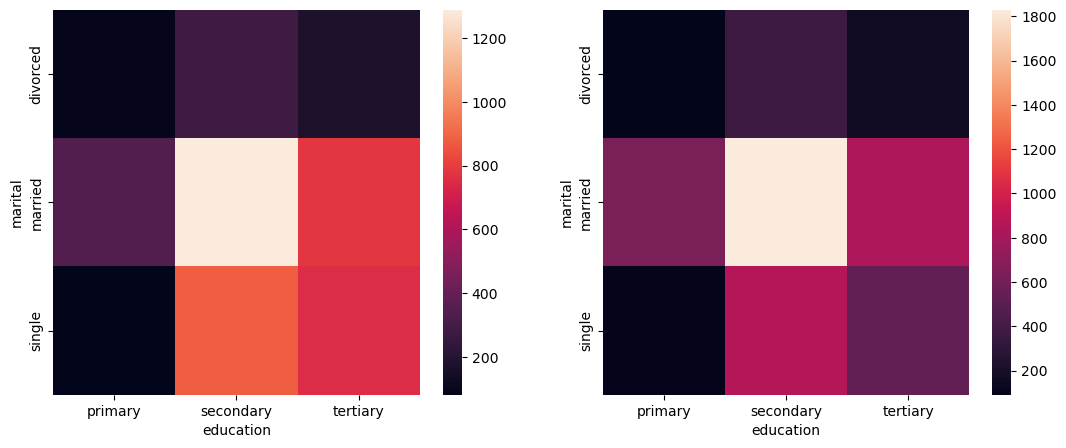

In [26]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

df_deposit_data = pd.pivot_table(
                        df_deposit,
                        values='deposit',
                        index='marital',
                        columns='education',
                        aggfunc='count',
                        fill_value=0  # заменяем NaN на 0
                    )

heatmap = sns.heatmap(data=df_deposit_data,
                      ax=axes[0])

df_no_deposit_data = pd.pivot_table(
                        df_no_deposit,
                        values='deposit',
                        index='marital',
                        columns='education',
                        aggfunc='count',
                        fill_value=0  # заменяем NaN на 0
                    )

heatmap = sns.heatmap(data=df_no_deposit_data,
                     ax=axes[1])

## Часть 3: преобразование данных

### Задание 1

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [28]:
# преобразуйте уровни образования
df_encode = df_clean.copy()

df_encode['education'] = le.fit_transform(df_encode['education'])
df_encode['age_group'] = le.fit_transform(df_encode['age_group'])

In [29]:
l_test = df_encode['education'].sum()
print(l_test)

11995


### Задания 2 и 3

In [30]:
# преобразуйте бинарные переменные в представление из нулей и единиц
df_encode['deposit'] = df_encode['deposit'].apply(lambda x: 1 if x =='yes' else 0)
df_encode['default'] = df_encode['default'].apply(lambda x: 1 if x =='yes' else 0)
df_encode['housing'] = df_encode['housing'].apply(lambda x: 1 if x =='yes' else 0)
df_encode['loan'] = df_encode['loan'].apply(lambda x: 1 if x =='yes' else 0)

In [31]:
std_dev = df_encode['deposit'].std()
print(round(std_dev,3))

0.499


In [32]:
mean_default = df_encode['default'].mean()
mean_housing = df_encode['housing'].mean()
mean_loan = df_encode['loan'].mean()
mean_test = round(mean_default+mean_housing+mean_loan,3)
print(mean_test)

0.635


### Задание 4

In [33]:
# создайте дамми-переменные
df_encode = pd.get_dummies(df_encode,columns=['job','marital','contact','month','poutcome'])
print(df_encode.shape[1]-1+5)

50


### Задания 5 и 6

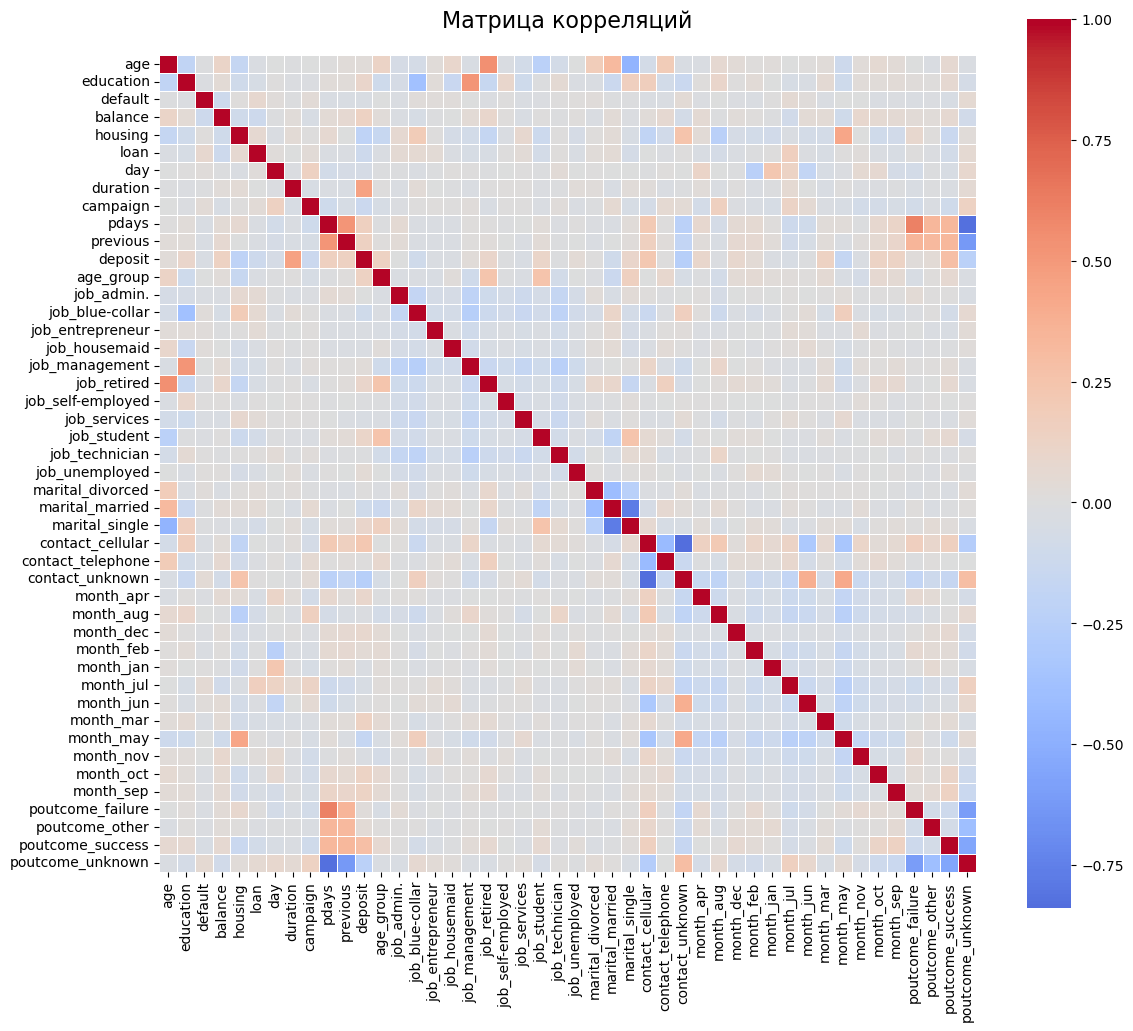

In [34]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
correlation_matrix = df_encode.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(
    correlation_matrix,
    annot=False,           # Показываем значения в ячейках
    fmt='.2f',          # Формат чисел: 2 знака после запятой
    cmap='coolwarm',    # Цветовая схема
    center=0,         # Центр цветовой шкалы на 0
    square=True,      # Квадратные ячейки
    linewidths=0.5, # Толщина линий между ячейками
    cbar_kws={"shrink": .8}  # Настройка цветовой шкалы
)
plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [35]:
# Извлекаем корреляции с целевой переменной
deposit_corr = correlation_matrix['deposit'].drop('deposit')  # Убираем самокорреляцию (1.0)

# Сортируем по убыванию абсолютного значения корреляции
deposit_corr_sorted = deposit_corr.abs().sort_values(ascending=False)

# Восстанавливаем знаки корреляций после сортировки
deposit_corr_final = deposit_corr[deposit_corr_sorted.index]

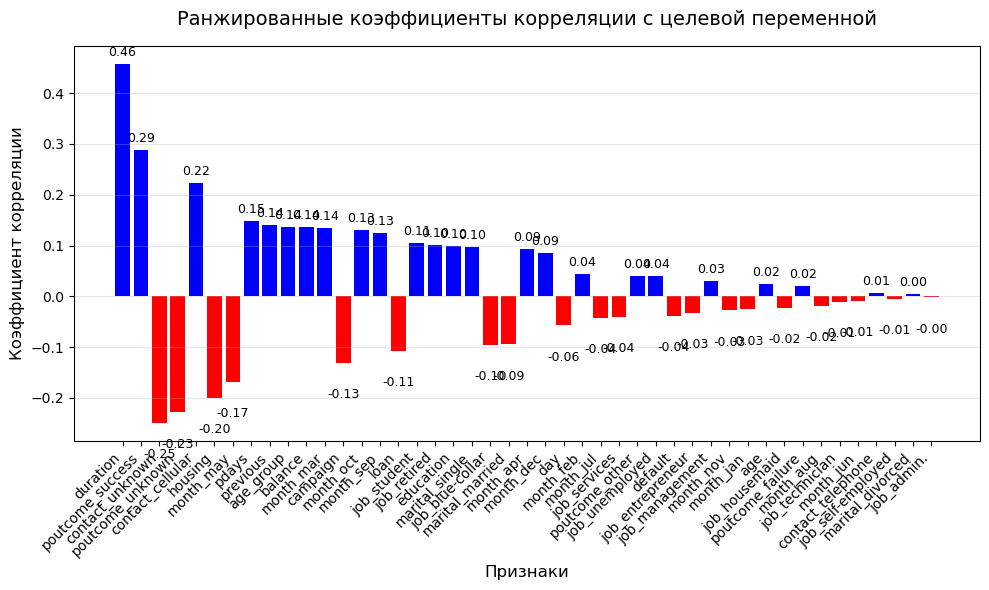

In [36]:
plt.figure(figsize=(10, 6))

# Создаём столбчатую диаграмму
bars = plt.bar(
    deposit_corr_final.index,
    deposit_corr_final.values,
    color=['red' if x < 0 else 'blue' for x in deposit_corr_final.values]  # Красный для отрицательных, синий для положительных
)

plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Коэффициент корреляции', fontsize=12)
plt.title('Ранжированные коэффициенты корреляции с целевой переменной', fontsize=14, pad=15)

# Добавляем значения на столбцы
for bar, value in zip(bars, deposit_corr_final.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01 if value >= 0 else bar.get_height() - 0.05,
        f'{value:.2f}',
        ha='center', va='bottom' if value >= 0 else 'top',
        fontsize=9
    )

plt.xticks(rotation=45, ha='right')  # Поворот подписей на оси X
plt.grid(axis='y', alpha=0.3)  # Добавляем сетку по оси Y
plt.tight_layout()

### Задания 7 и 8

In [37]:
X = df_encode.drop(['deposit'], axis=1)
y = df_encode['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [38]:
# рассчитайте необходимые показатели
round(y_test.mean(),2)

np.float64(0.46)

### Задание 9

In [39]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
from sklearn.feature_selection import SelectKBest
select_best_sign = SelectKBest(score_func=f_classif, k=15)

In [40]:
X_best = select_best_sign.fit_transform(X_train, y_train)
best_sign = select_best_sign.get_feature_names_out()
X_best = pd.DataFrame(X_best, columns=best_sign)
display(X_best.shape)
print(best_sign)

(6770, 15)

['balance' 'housing' 'duration' 'campaign' 'pdays' 'previous' 'age_group'
 'contact_cellular' 'contact_unknown' 'month_mar' 'month_may' 'month_oct'
 'month_sep' 'poutcome_success' 'poutcome_unknown']


In [41]:
X_train = X_train[best_sign]
X_test = X_test[best_sign]

### Задание 10

In [42]:
# нормализуйте данные с помощью minmaxsxaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [43]:
round(X_test_norm[:,0].mean(),2)

np.float64(0.47)

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [48]:
# обучите логистическую регрессию и рассчитайте метрики качества
#Создаем объект класса логистическая регрессия
log_reg = linear_model.LogisticRegression(
    #penalty='l1',
    #C=0.3,
    solver='sag', #алгоритм оптимизации
    random_state=42, #генератор случайных чисел
    max_iter=1000 #количество итераций на сходимость
)
#Обучаем модель, минимизируя logloss
log_reg.fit(X_train_norm, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'sag'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
#Делаем предсказание для тренировочной выборки
# print('**** Тренировочные данные ***************************')
# y_train_pred = log_reg.predict(X_train_norm)
# #Вывод отчет о метриках классификации
# print(metrics.classification_report(y_train, y_train_pred))
# print('*****************************************************')

print('**** Тестовые данные ********************************')
#Делаем предсказание для тестовой выборки
y_test_pred = log_reg.predict(X_test_norm)
#Вывод отчет о метриках классификации
print(metrics.classification_report(y_test, y_test_pred))
print('*****************************************************')

**** Тестовые данные ********************************
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1790
           1       0.83      0.73      0.78      1545

    accuracy                           0.80      3335
   macro avg       0.81      0.80      0.80      3335
weighted avg       0.81      0.80      0.80      3335

*****************************************************


### Задания 2,3,4

In [91]:
# обучите решающие деревья, настройте максимальную глубину
#Создаём объект класса случайный лес
dt_clf_2d = tree.DecisionTreeClassifier(
    criterion='entropy',
    #max_depth=6,
    random_state=42
)
#Обучаем дерево решений по алгоритму CART
dt_clf_2d.fit(X_train_norm, y_train)

# #Делаем предсказание класса
# y_pred = rf_clf_2d.predict(X_test_norm)
# #Выводим отчёт о метриках
# print(metrics.classification_report(y_test, y_pred))

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [92]:
#Делаем предсказание для тренировочной выборки
print('**** Тренировочные данные ***************************')
y_train_pred = dt_clf_2d.predict(X_train_norm)
#Вывод отчет о метриках классификации
print(metrics.classification_report(y_train, y_train_pred))
print('*****************************************************')

print('**** Тестовые данные ********************************')
#Делаем предсказание для тестовой выборки
y_test_pred = dt_clf_2d.predict(X_test_norm)
#Вывод отчет о метриках классификации
print(metrics.classification_report(y_test, y_test_pred))
print('*****************************************************')

**** Тренировочные данные ***************************
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3634
           1       1.00      1.00      1.00      3136

    accuracy                           1.00      6770
   macro avg       1.00      1.00      1.00      6770
weighted avg       1.00      1.00      1.00      6770

*****************************************************
**** Тестовые данные ********************************
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      1790
           1       0.74      0.71      0.72      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.74      0.75      3335
weighted avg       0.75      0.75      0.75      3335

*****************************************************


### Задание 5

In [93]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV
#Формирвем пространство гиперпараметров
param_grid = {'min_samples_split': [2, 5, 7, 10],
              'max_depth': [3,5,7]
              }

In [94]:
grid_search_forest = GridSearchCV(
    estimator=dt_clf_2d,
    param_grid=param_grid
)
%time grid_search_forest.fit(X_train_norm, y_train)
y_train_pred = grid_search_forest.predict(X_train_norm)
print('f1_score на обучающем наборе: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
print("accuracy на тестовом наборе: {:.2f}".format(grid_search_forest.score(X_test_norm, y_test)))
y_test_pred = grid_search_forest.predict(X_test_norm)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search_forest.best_params_))

CPU times: total: 609 ms
Wall time: 604 ms
f1_score на обучающем наборе: 0.82
accuracy на тестовом наборе: 0.82
f1_score на тестовом наборе: 0.81
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 10}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [99]:
# обучите на ваших данных случайный лес
#Создаём объект класса случайный лес
rf_clf_2d = ensemble.RandomForestClassifier(
    n_estimators=100, #число деревьев
    criterion='gini', #критерий эффективности
    max_depth=10, #максимальная глубина дерева
    min_samples_leaf = 5,
    #max_features='sqrt', #число признаков из метода случайных подространств
    random_state=42 #генератор случайных чисел
)
#Обучаем модель
rf_clf_2d.fit(X_train_norm, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
print('**** Тестовые данные ********************************')
#Делаем предсказание для тестовой выборки
y_test_pred = rf_clf_2d.predict(X_test_norm)
#Вывод отчет о метриках классификации
print(metrics.classification_report(y_test, y_test_pred))
print('*****************************************************')

**** Тестовые данные ********************************
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335

*****************************************************


### Задания 2 и 3

In [109]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error

# Создаем объект класса градиентный бустинг
gb = GradientBoostingClassifier(
    learning_rate = 0.05,
    min_samples_leaf = 5,
    max_depth=5, #максимальная глубина дерева
    n_estimators=300, #количество деревьев в ансамбле
    random_state=42 #датчик генератора случайных чисел
)

# Обучаем модель
gb.fit(X_train_norm, y_train)

# Формируем предсказание для тестовой выборки
gb_pred  = gb.predict(X_test_norm)

# Оцениваем качество по метрике MSE
print(metrics.classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 4

In [116]:
# объедините уже известные вам алгоритмы с помощью стекинга
from sklearn.ensemble import StackingClassifier
# Создаем список кортежей вида: (наименование модели, модель)
estimators = [
    ('lr', log_reg),
    ('dt', dt_clf_2d),
    ('gb', gb)
]

# Создаем объект класса стекинг
reg = StackingClassifier(estimators=estimators,
                         final_estimator=linear_model.LogisticRegression(
                                        #penalty='l1',
                                        #C=0.3,
                                        solver='sag', #алгоритм оптимизации
                                        random_state=42, #генератор случайных чисел
                                        max_iter=1000 #количество итераций на сходимость
                    )
)
# Обучаем модель
reg.fit(X_train_norm, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegre... solver='sag')
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [117]:

# Формируем предсказание для тестовой выборки
reg_pred  = reg.predict(X_test_norm)
print(metrics.classification_report(y_test, reg_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1790
           1       0.81      0.81      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335



### Задание 5

In [ ]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
# Получение важности признаков
feature_importance = gb.feature_importances_

# Сортировка по важности
sorted_idx = np.argsort(feature_importance)[::-1]

# Вывод результатов
for i in sorted_idx:
    print(f"Признак {i}: {feature_importance[i]:.4f}")

Признак 2: 0.5015
Признак 13: 0.1162
Признак 8: 0.0740
Признак 0: 0.0606
Признак 4: 0.0551
Признак 1: 0.0469
Признак 6: 0.0418
Признак 9: 0.0261
Признак 11: 0.0191
Признак 3: 0.0173
Признак 10: 0.0140
Признак 12: 0.0134
Признак 5: 0.0091
Признак 7: 0.0045
Признак 14: 0.0004


### Задания 6,7,8

In [ ]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
# задаем пространства поиска гиперпараметров
def optuna_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

    # создаем модель
    model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                            max_depth=max_depth,
                                            min_samples_leaf=min_samples_leaf,
                                            random_state=42)
    # обучаем модель
    model.fit(X_train_norm, y_train)
    #score = metrics.f1_score(y_test, model.predict(X_test_norm))
    score = metrics.accuracy_score(y_test, model.predict(X_test_norm))
    # применим  cross validation использованием 5 фолдов
    #score = cross_val_score(model, X, y, cv=5, scoring="f1", n_jobs=-1).mean()
    return score

In [141]:
%%time
import optuna
# cоздаем объект исследования
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)

# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на тестовом наборе: {:.2f}".format(study.best_value))

[I 2026-03-03 16:12:17,987] A new study created in memory with name: RandomForestClassifier
[I 2026-03-03 16:12:19,617] Trial 0 finished with value: 0.8275862068965517 and parameters: {'n_estimators': 173, 'max_depth': 11, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-03 16:12:21,173] Trial 1 finished with value: 0.8257871064467767 and parameters: {'n_estimators': 147, 'max_depth': 21, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-03 16:12:22,955] Trial 2 finished with value: 0.8272863568215892 and parameters: {'n_estimators': 174, 'max_depth': 26, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-03 16:12:24,026] Trial 3 finished with value: 0.8218890554722639 and parameters: {'n_estimators': 118, 'max_depth': 28, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.8275862068965517.
[I 2026-03-03 16:12:25,766] Trial 4 finished with value: 0.8251874062968516 and parameters: {'n

Наилучшие значения гиперпараметров {'n_estimators': 141, 'max_depth': 14, 'min_samples_leaf': 3}
f1_score на тестовом наборе: 0.83
CPU times: total: 29.2 s
Wall time: 29.3 s
